In [42]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)


# Imports
from stn_gpe import *
import numpy as np
from matplotlib import pyplot as plt
import scipy
from numpy.fft import fft, ifft
import math

# rc styling (Times New Roman + nicer defaults)
# ...existing code...
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "font.weight": "bold",         # global bold
    "axes.titlesize": 12,
    "axes.titleweight": "bold",    # bold axis titles
    "axes.labelsize": 11,
    "axes.labelweight": "bold",    # bold axis labels
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.grid": False
})
# ...existing code...

Project root added to sys.path: d:\charitha\projects\STN-GPe_spiking\STN_GPe_simulations


## Run STN-GPe system

In [20]:
# Parameters file
yaml_path = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_Normal.yaml')
arguments = load_yaml(yaml_path)


# Simulate STN-GPe system
results = STN_GPe_loop(yaml_path)

  0%|          | 0/50000 [00:00<?, ?it/s]

## Analysis

In [21]:
V_stn_time_all = results['v_stn']
V_gpe_time_all = results['v_gpe']
spike_monitor_stn = results['spike_stn']
spike_monitor_gpe = results['spike_gpe']
lfp_stn = results['lfp_stn']
lfp_gpe = results['lfp_gpe']
I_DBS = results['I_DBS']

In [22]:
analysis_STN = Analysis(spike_monitor_stn[30000:50000])
analysis_GPe = Analysis(spike_monitor_gpe[30000:50000])

In [23]:
iter = arguments.get('time')
h = arguments.get('dt')
t = np.linspace(0,iter*h/1000,iter)

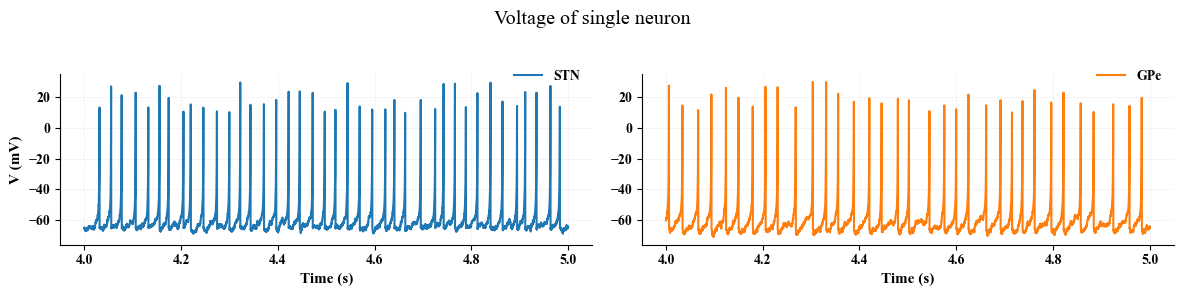

In [55]:

# ensure arrays
t = np.asarray(t)
V_stn_arr = np.asarray(V_stn_time_all)   # shape: (time, nx, ny)
V_gpe_arr = np.asarray(V_gpe_time_all)

# select last 1 second
end_t = t[-1]
start_t = max(t[0], end_t - 1.0)
mask = (t >= start_t) & (t <= end_t)
t_sel = t[mask]

# pick single neuron (7,7)
v_stn_sel = V_stn_arr[:, 7, 7][mask]
v_gpe_sel = V_gpe_arr[:, 7, 7][mask]



# create figure with white background, axes visible but no outer frame line
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 3), facecolor='white')
fig.patch.set_visible(True)
fig.patch.set_facecolor('white')   # full-figure background white
fig.patch.set_edgecolor('white')   # ensure no visible edge
fig.patch.set_linewidth(0)
fig.subplots_adjust(wspace=0.3, left=0.06, right=0.98, top=0.92, bottom=0.15)

# STN
ax = axs[0]
ax.plot(t_sel, v_stn_sel, color="tab:blue")
# ax.set_title("STN")
ax.set_xlabel("Time (s)")
ax.set_ylabel("V (mV)")
ax.legend(["STN"], loc="upper right", frameon = False, bbox_to_anchor=(1.0, 1.1))

# GPe
ax = axs[1]
ax.plot(t_sel, v_gpe_sel, color="tab:orange")
# ax.set_title("GPe")
ax.set_xlabel("Time (s)")
ax.legend(["GPe"], loc="upper right", frameon = False, bbox_to_anchor=(1.0, 1.1))

# show only left and bottom spines, keep ticks/axes visible, white axes background
for ax in axs:
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    for spine in ['left','bottom']:
        ax.spines[spine].set_linewidth(0.8)
        ax.spines[spine].set_color('black')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.25)
fig.suptitle('Voltage of single neuron')
plt.tight_layout()
plt.show()


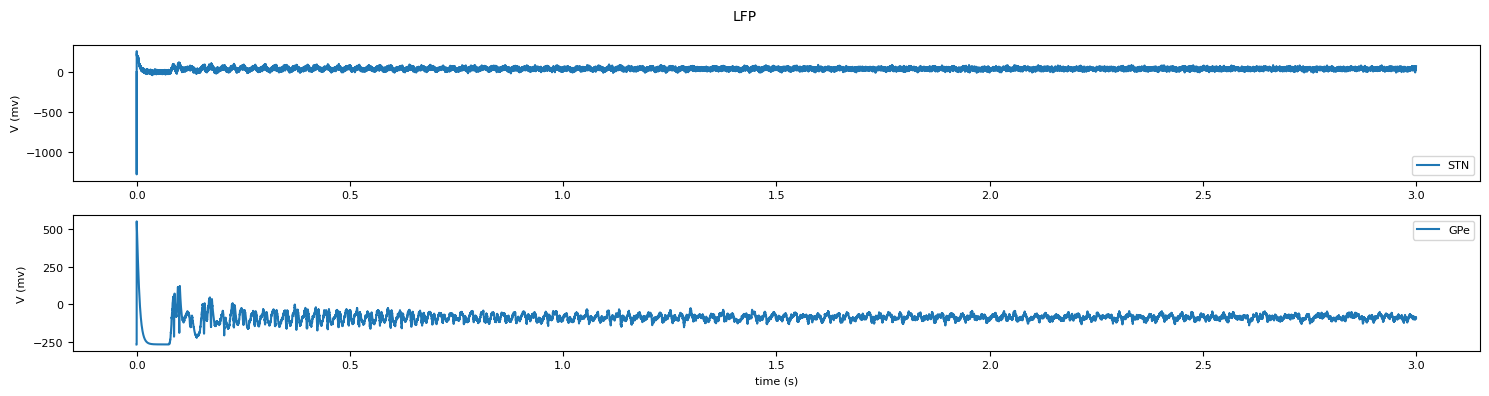

In [ ]:
# LFP of neuronal population
plt.figure(figsize=(15,4))
plt.subplot(211)
plt.suptitle('LFP', fontsize = 10)
plt.plot(t, lfp_stn, label = 'STN')
plt.ylabel('V (mv)',fontsize = 8)
# plt.ylim(-100,150)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.legend(fontsize = 8)
plt.subplot(212)
plt.plot(t, lfp_gpe, label = 'GPe')
# plt.ylim(-25,50)
# plt.title('GPe: LFP', fontsize = 8)
plt.xlabel('time (s)',fontsize = 8)
plt.ylabel('V (mv)',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.tight_layout()
plt.legend(fontsize = 8)
plt.show()


30000


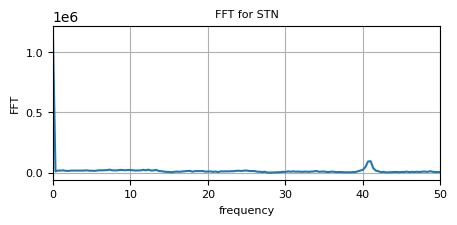

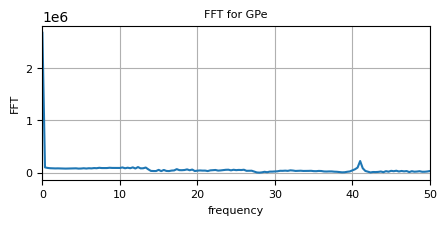

In [ ]:
# FFT of LFP

 # Smoothening the LFP signal
lfp_smooth_stn = scipy.signal.savgol_filter(lfp_stn, window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
lfp_smooth_gpe = scipy.signal.savgol_filter(lfp_gpe, window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)

# FFT computation for STN
sr = 10000
fft_output_stn = fft(lfp_stn)
fft_output_gpe = fft(lfp_smooth_gpe)
N = len(fft_output_stn)
print(N)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (5,2))
plt.plot(freq, np.abs(fft_output_stn)) #(np.abs(fft_output_stn)/np.linalg.norm(np.abs(fft_output_stn))))
# plt.plot(freq,np.abs(fft_output_stn))
plt.xlim(0,50)
# plt.ylim(0,0.5e6)
plt.title('FFT for STN',fontsize="8")
plt.xlabel('frequency',fontsize="8")
plt.ylabel('FFT',fontsize="8")
plt.xticks(fontsize="8")
plt.yticks(fontsize = '8')
# plt.ylim(0,0.5e6)
plt.grid()

plt.figure(figsize = (5,2))
plt.plot(freq, np.abs(fft_output_gpe))#(np.abs(fft_output_gpe)/np.linalg.norm(np.abs(fft_output_gpe))))
#plt.plot(freq,np.abs(fft_output_gpe))
plt.xlim(0,50)
# plt.ylim(0,80000)
plt.title('FFT for GPe',fontsize="8")
plt.xlabel('frequency',fontsize="8")
plt.ylabel('FFT',fontsize="8")
plt.xticks(fontsize="8")
plt.yticks(fontsize = '8')
plt.grid()

In [ ]:
avg_entropy_stn = analysis_STN.spectral_entropy(signal=lfp_stn[10000:20000],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)
avg_entropy_gpe = analysis_STN.spectral_entropy(signal=lfp_gpe[10000:20000],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)
print(f'Average GPe entropy = {avg_entropy_gpe}')
print(f'Average STN entropy = {avg_entropy_stn}')


Average GPe entropy = 0.7457724370654797
Average STN entropy = 0.8416315485117055


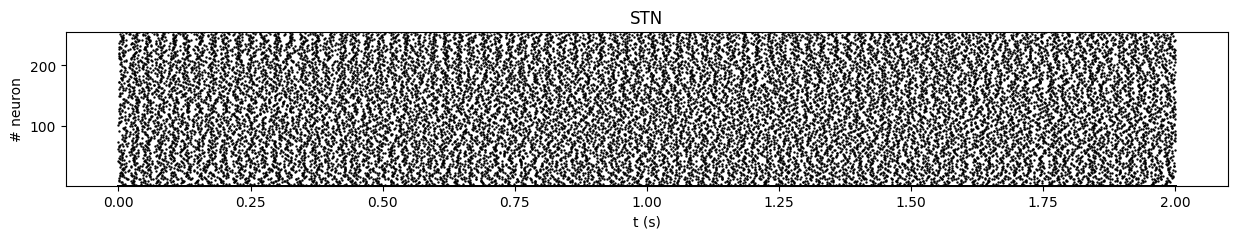

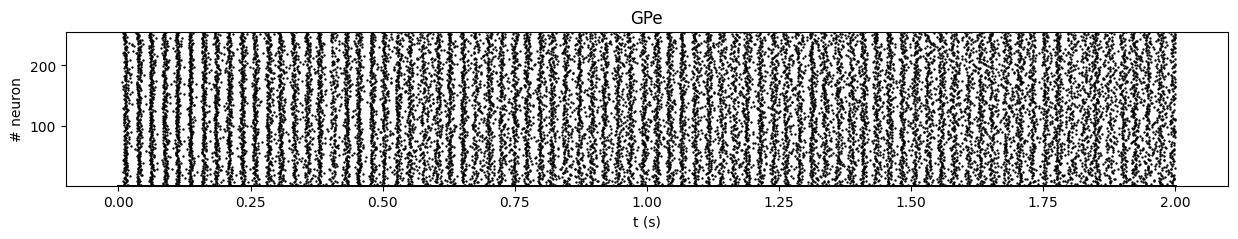

In [ ]:
# Raster plot
analysis_STN.raster_plot(title = 'STN', h = h)
analysis_GPe.raster_plot(title = 'GPe', h = h)

Average STN sync = 0.15798990492540246, Average GPe sync = 0.42932963077074776


Text(0, 0.5, 'Rsync')

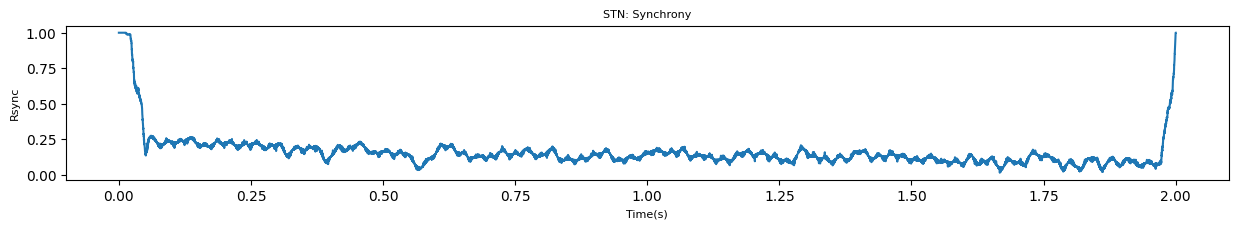

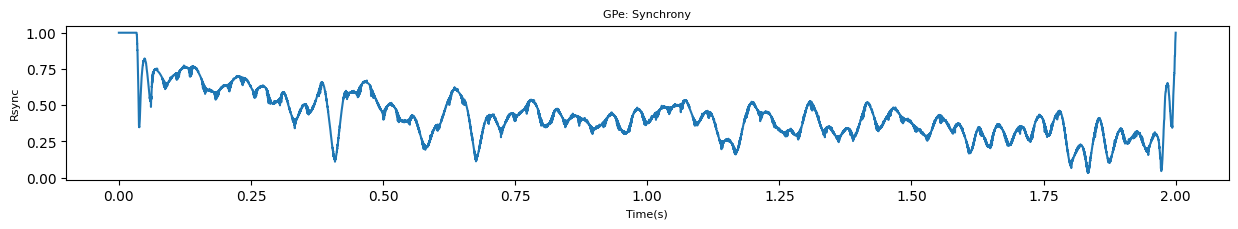

In [ ]:
# Synchrony
iter_ = 20000
t_ = np.linspace(0,iter_*h/1000,iter_)
R_sync_stn, Ravg_stn = analysis_STN.synchrony()
R_sync_gpe, Ravg_gpe = analysis_GPe.synchrony()
print(f'Average STN sync = {Ravg_stn}, Average GPe sync = {Ravg_gpe}')
plt.figure(figsize =(15,2))
plt.plot(t_ , np.abs(R_sync_stn))
plt.title('STN: Synchrony',fontsize = 8)
plt.xlabel('Time(s)',fontsize = 8)
plt.ylabel('Rsync', fontsize = 8)

plt.figure(figsize=(15,2))
plt.plot(t_ , np.abs(R_sync_gpe))
plt.title('GPe: Synchrony', fontsize = 8)
plt.xlabel('Time(s)',fontsize = 8)
plt.ylabel('Rsync',fontsize = 8)

In [ ]:
print(f'Average STN sync = {np.round(Ravg_stn,2)}, Average GPe sync = {np.round(Ravg_gpe,2)}')

Average STN sync = 0.16, Average GPe sync = 0.43


In [ ]:
# spike to rate conversion
rate_data = analysis_STN.spike_rate(binsize = 100)

stn_a, stn_b, stn_c, stn_d = rate_data['1'], rate_data['2'], rate_data['3'], rate_data['4']
rate_all = rate_data['all_rate_data']
preprocessed_stn = rate_data['preprocessed_stn']
processed_stn = rate_data['processed_stn']
mean_std = rate_data['mean_std']
max_std = rate_data['max_std']
min_std = rate_data['min_std']
print(f'STD: mean: {mean_std}, min: {min_std}, max: {max_std}')

2 20000
STD: mean: 0.19214646348320133, min: 0.007896679801520605, max: 0.528452622056773


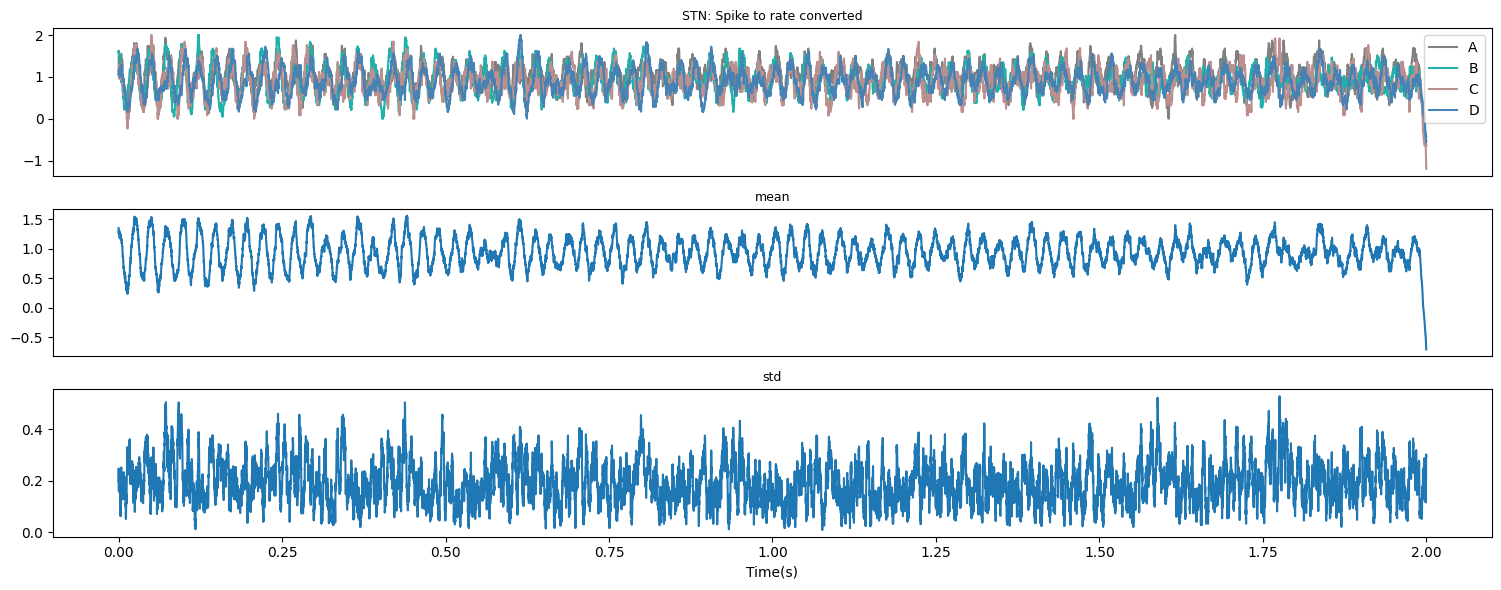

In [ ]:
# Spike to rate output of STN
plt.figure(figsize  = (15,6))
plt.subplot(3,1,1)
plt.plot(t_,preprocessed_stn[0], label = 'A', color = 'gray')
plt.plot(t_,preprocessed_stn[1], label = 'B', color = 'lightseagreen')
plt.plot(t_,preprocessed_stn[2], label = 'C', color = 'rosybrown')
plt.plot(t_,preprocessed_stn[3], label = 'D', color = 'steelblue')
# plt.xlim(4.5,5.0)
plt.xticks([])
plt.title('STN: Spike to rate converted', fontsize = 9)
plt.legend(loc = 'upper right')


plt.subplot(3,1,2)
plt.plot(t_, np.mean(preprocessed_stn, axis = 0))
plt.title("mean", fontsize = 9)
plt.xticks([])
# plt.xlim(4.5,5.0)

plt.subplot(3,1,3)
plt.plot(t_, np.std(preprocessed_stn, axis = 0))
# plt.xlim(4.5,5.0)
plt.title("std", fontsize = 9)
plt.xlabel('Time(s)')
plt.tight_layout()

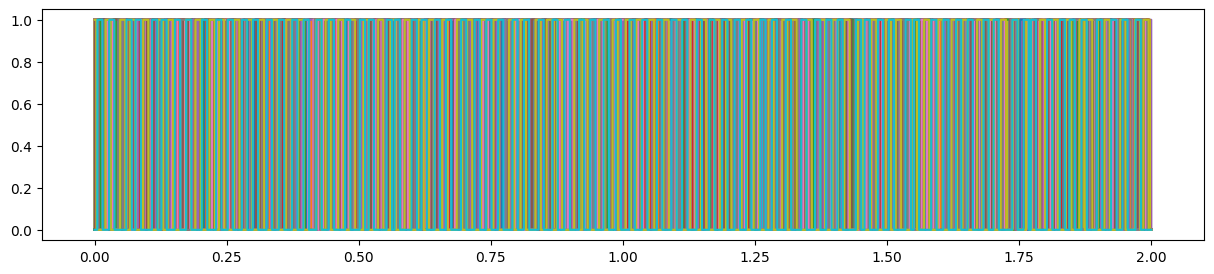

In [ ]:
rate_coded = rate_all.reshape(rate_all.shape[0] * rate_all.shape[1], rate_all.shape[2])
rate_coded.shape
plt.figure(figsize=(15,3))
for i in range(50):
    plt.plot(t_,rate_coded[i])


(0.0, 0.2)

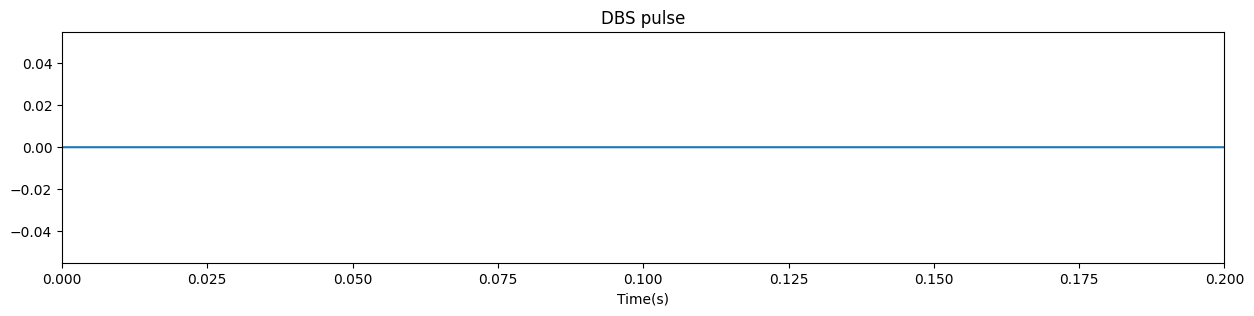

In [ ]:
# Spike to rate output of STN
plt.figure(figsize  = (15,3))

plt.plot(t,I_DBS)

plt.xlabel('Time(s)')
plt.title('DBS pulse')
plt.xlim(0,0.2)

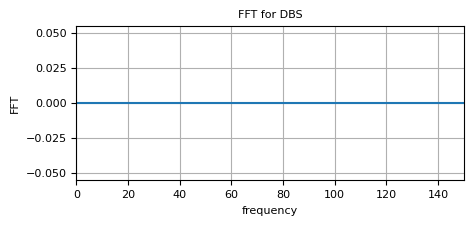

In [ ]:
# FFT computation for STN
sr = 10000
fft_dbs= fft(I_DBS)
N = len(fft_dbs)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (5,2))
plt.plot(freq, np.abs(fft_dbs)) #(np.abs(fft_output_stn)/np.linalg.norm(np.abs(fft_output_stn))))
# plt.plot(freq,np.abs(fft_output_stn))
plt.xlim(0,150)
# plt.ylim(0,0.5e6)
plt.title('FFT for DBS',fontsize="8")
plt.xlabel('frequency',fontsize="8")
plt.ylabel('FFT',fontsize="8")
plt.xticks(fontsize="8")
plt.yticks(fontsize = '8')
plt.grid()


In [ ]:
frequency_avg, frequency_max, frequency_min = analysis_STN.frequency(dt = h)
print(f'STN: freq = {np.round(frequency_avg,2)}, freq_max = {np.round(frequency_max,2)}, freq_min = {np.round(frequency_min,2)}')

frequency_avg, frequency_max, frequency_min = analysis_GPe.frequency(dt = h)
print(f'GPe: freq = {np.round(frequency_avg,2)}, freq_max = {np.round(frequency_max,2)}, freq_min = {np.round(frequency_min,2)}')

STN: freq = 40.87, freq_max = 41.5, freq_min = 40.5
GPe: freq = 35.62, freq_max = 41.0, freq_min = 26.0


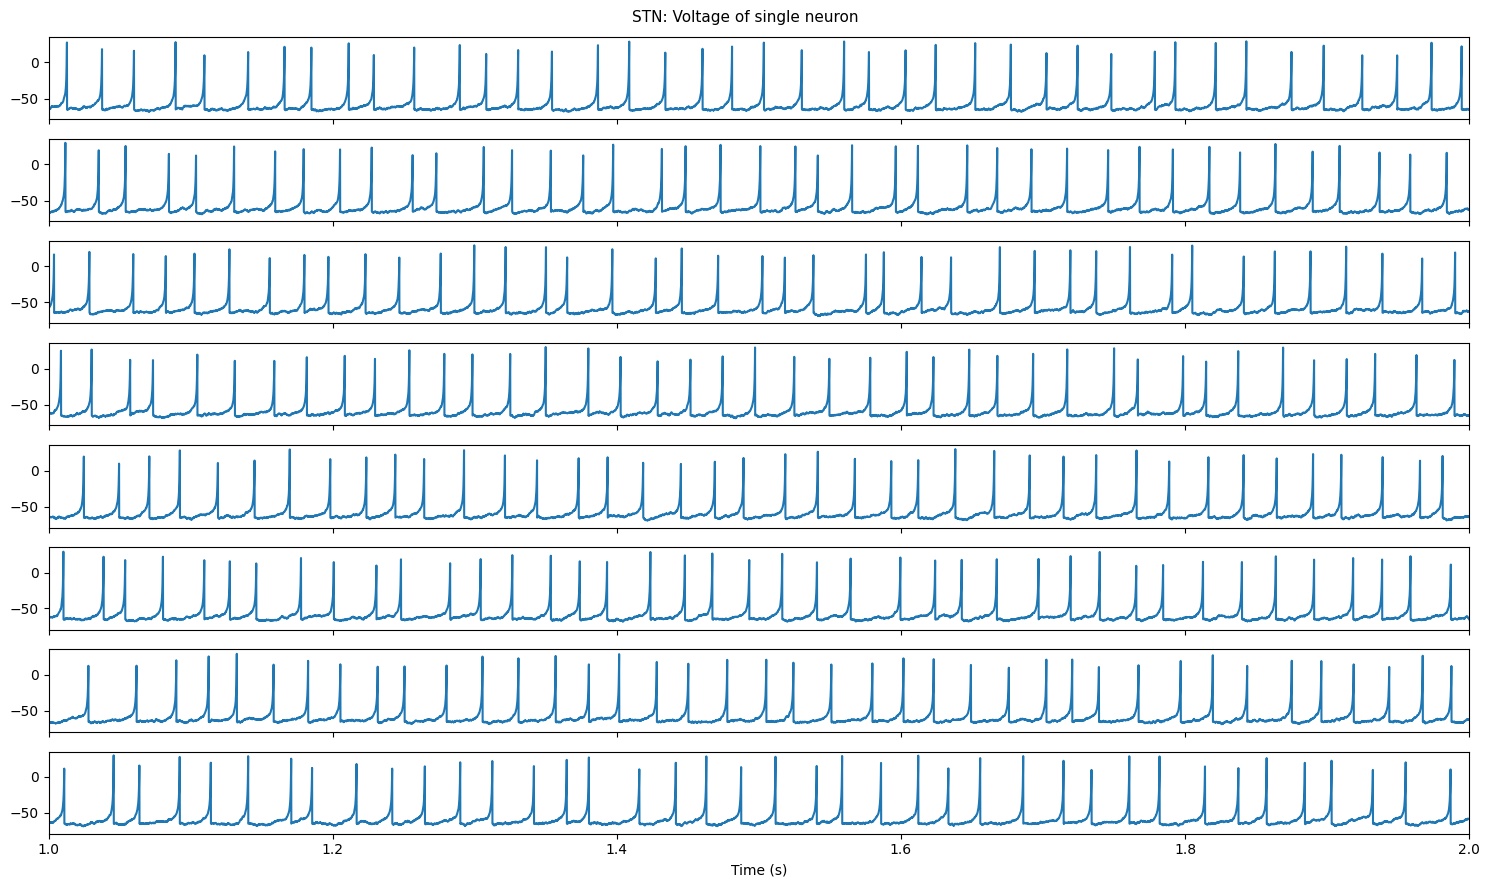

In [ ]:
fig, axs = plt.subplots(8, 1, sharex=True, figsize=(15, 9))
plt.suptitle('STN: Voltage of single neuron', fontsize=11)

for i in range(8):
    axs[i].plot(t, np.array(V_stn_time_all)[:,np.random.choice(np.arange(16)),np.random.choice(np.arange(16))])

for ax in axs:
    ax.set_xlim(1, 2)  # Set the desired x-axis limits

axs[-1].set_xlabel('Time (s)')
plt.tight_layout()

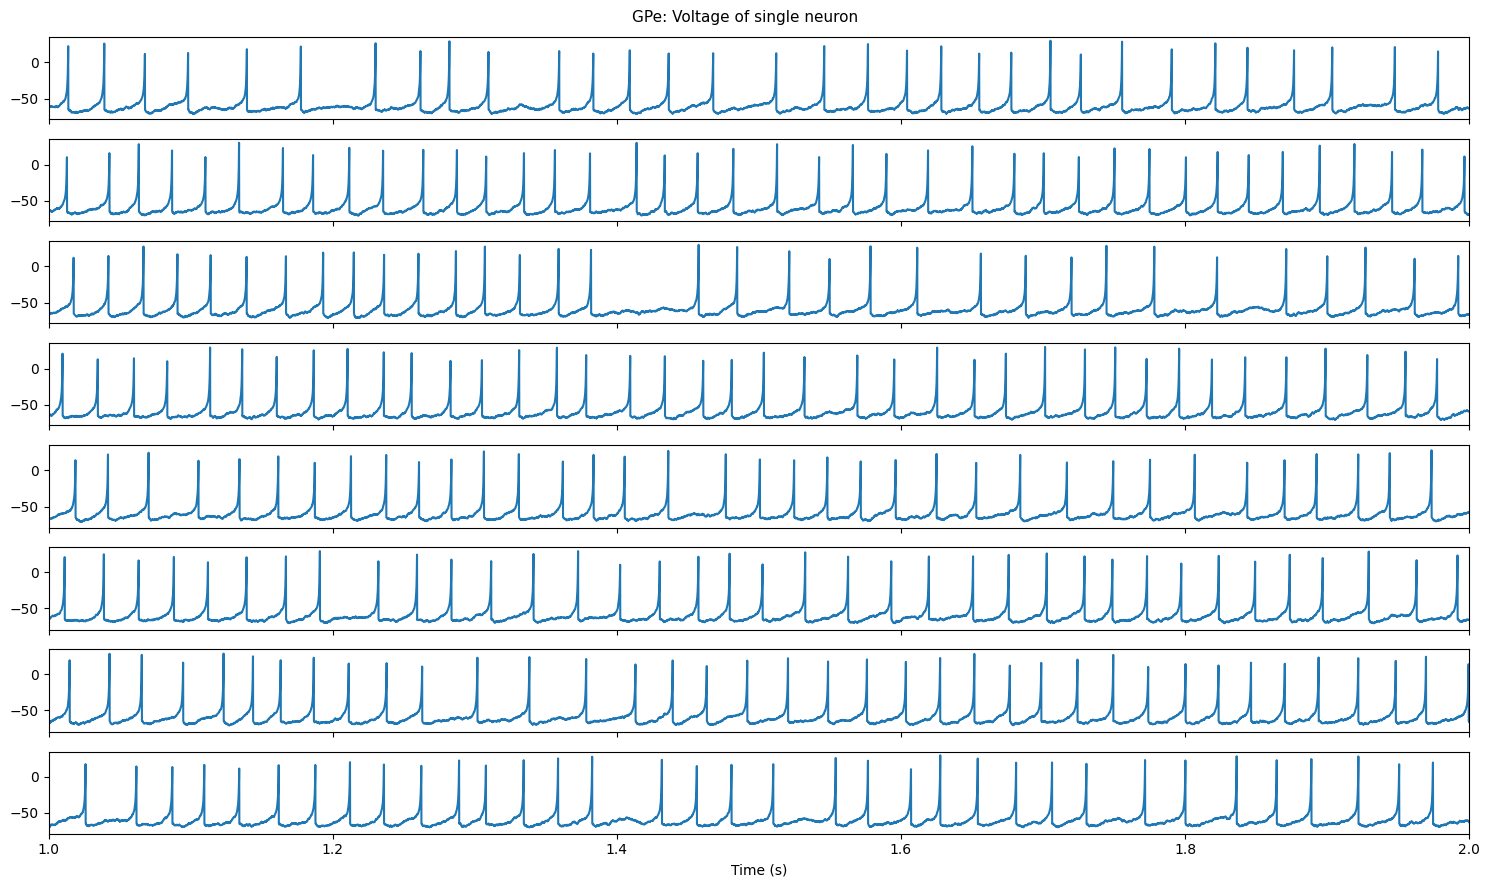

In [ ]:
fig, axs = plt.subplots(8, 1, sharex=True, figsize=(15, 9))
plt.suptitle('GPe: Voltage of single neuron', fontsize=11)

for i in range(8):
    axs[i].plot(t, np.array(V_gpe_time_all)[:,np.random.choice(np.arange(16)),np.random.choice(np.arange(16))])

for ax in axs:
    ax.set_xlim(1, 2)  # Set the desired x-axis limits

axs[-1].set_xlabel('Time (s)')
plt.tight_layout()